<a href="https://colab.research.google.com/github/oliviaguo1234/lendingclub_loans/blob/main/OliviaGuo_loans.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Data Cleaning

In [2]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
from sklearn.feature_selection import SelectKBest
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, accuracy_score

In [3]:
import pandas as pd
import numpy as np

url = "https://raw.githubusercontent.com/frontiertechinstitute/datasets/refs/heads/main/LendingClub%20Loans/lendingclub_loans_export.csv"
loans_df = pd.read_csv(url)

#Change NA values to null
loans_df = loans_df.replace("NA", np.nan)

#Droped join annual income columns (>85% null rate for both)
loans_df.drop(columns = ["annual_income_joint", "verification_income_joint", "debt_to_income_joint"], inplace = True)

#All loans were 2018, remove year from issue month
loans_df["issue_month"] = pd.to_datetime(loans_df["issue_month"], format="%b-%Y").dt.strftime('%B')

#Grade information included in subgrade
loans_df.drop(columns = ["grade"], inplace = True)

loans_df.to_csv("lendingclub_loans_clean.csv")

In [4]:
loans_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 51 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   emp_title                         9167 non-null   object 
 1   emp_length                        9183 non-null   float64
 2   state                             10000 non-null  object 
 3   homeownership                     10000 non-null  object 
 4   annual_income                     10000 non-null  float64
 5   verified_income                   10000 non-null  object 
 6   debt_to_income                    9976 non-null   float64
 7   delinq_2y                         10000 non-null  int64  
 8   months_since_last_delinq          4342 non-null   float64
 9   earliest_credit_line              10000 non-null  int64  
 10  inquiries_last_12m                10000 non-null  int64  
 11  total_credit_lines                10000 non-null  int64  
 12  open_

In [5]:
#Drop debt_to_income
loans_df = loans_df.dropna(how='any', subset=['debt_to_income']).copy()
#Replace months_since_last_delinq missing values with 0
loans_df['months_since_last_delinq'] = loans_df['months_since_last_delinq'].fillna(value=0)
#Replace null emp_title with "unknown"
loans_df['emp_title'] = loans_df['emp_title'].fillna(value = 'unknown')
#Replace num_accounts_120d_past_due missing values with 0
loans_df['num_accounts_120d_past_due'] = loans_df['num_accounts_120d_past_due'].fillna(value=0)
#Replace emp_length missing values with 0
loans_df['emp_length'] = loans_df['emp_length'].fillna(value=0)
loans_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9976 entries, 0 to 9999
Data columns (total 51 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   emp_title                         9976 non-null   object 
 1   emp_length                        9976 non-null   float64
 2   state                             9976 non-null   object 
 3   homeownership                     9976 non-null   object 
 4   annual_income                     9976 non-null   float64
 5   verified_income                   9976 non-null   object 
 6   debt_to_income                    9976 non-null   float64
 7   delinq_2y                         9976 non-null   int64  
 8   months_since_last_delinq          9976 non-null   float64
 9   earliest_credit_line              9976 non-null   int64  
 10  inquiries_last_12m                9976 non-null   int64  
 11  total_credit_lines                9976 non-null   int64  
 12  open_credit

In [6]:
#create separate column for months_since_90d_late called months_since_90d_relevance
loans_df['months_since_90d_relevance'] = loans_df['months_since_90d_late'].notnull()


#create separate column for months_since_last_credit_inquiry called months_since_credit_relevance
loans_df['months_since_credit_relevance'] = loans_df['months_since_last_credit_inquiry'].notnull()

In [7]:
loans_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9976 entries, 0 to 9999
Data columns (total 53 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   emp_title                         9976 non-null   object 
 1   emp_length                        9976 non-null   float64
 2   state                             9976 non-null   object 
 3   homeownership                     9976 non-null   object 
 4   annual_income                     9976 non-null   float64
 5   verified_income                   9976 non-null   object 
 6   debt_to_income                    9976 non-null   float64
 7   delinq_2y                         9976 non-null   int64  
 8   months_since_last_delinq          9976 non-null   float64
 9   earliest_credit_line              9976 non-null   int64  
 10  inquiries_last_12m                9976 non-null   int64  
 11  total_credit_lines                9976 non-null   int64  
 12  open_credit

# EDA

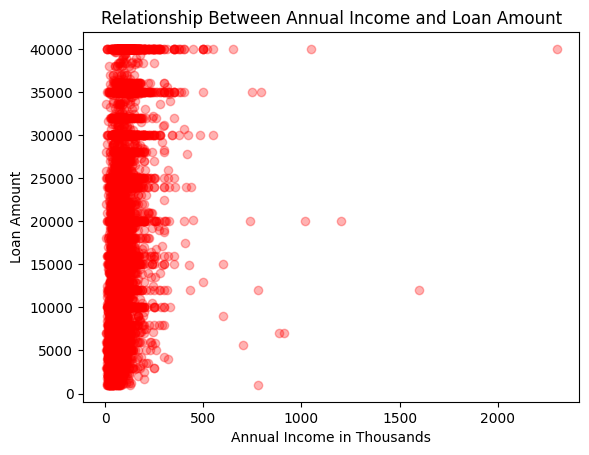

In [8]:
#find relationship between annual_income and loan_amount (do richer income people have higher loan amount?)
plt.scatter(loans_df['annual_income'] / 1000, loans_df['loan_amount'], color='red', alpha=0.3)
plt.xlabel('Annual Income in Thousands')
plt.ylabel('Loan Amount')
plt.title('Relationship Between Annual Income and Loan Amount')
plt.show()

**Observations**


*   Most borrowers have annual income less than 500,000, mostly around 200,000
*   Maximum loan amount: 40,000, likely a restriction by LendingClub
*   Weak relationship between income and loans amount (outlier of an individual earning ~2M but still taking out loan)



In [9]:
loans_df['issue_month'].unique()

array(['March', 'February', 'January'], dtype=object)

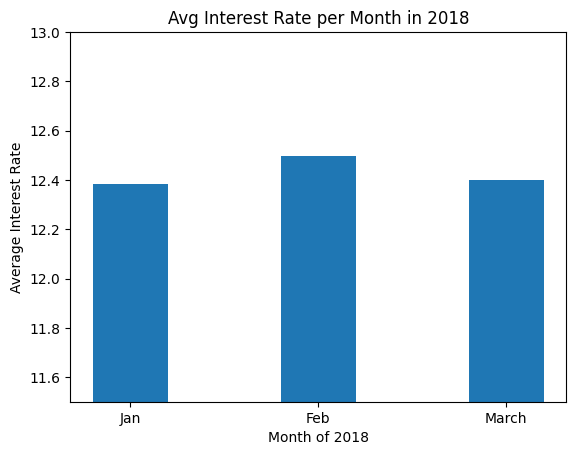

In [10]:
#line plot of issue month vs average interest rate: over 2018, what happens to avg interest rates?
jan_rows = loans_df[loans_df['issue_month'] == 'January']
jan_interest = jan_rows['interest_rate'].mean()
feb_rows = loans_df[loans_df['issue_month'] == 'February']
feb_interest = feb_rows['interest_rate'].mean()
mar_rows = loans_df[loans_df['issue_month'] == 'March']
mar_interest = mar_rows['interest_rate'].mean()
x_categories = ['Jan', 'Feb', 'March']
avg_interest = [jan_interest, feb_interest, mar_interest]
plt.bar(x_categories, avg_interest, width=0.4)
plt.xlabel('Month of 2018')
plt.ylabel('Average Interest Rate')
plt.title('Avg Interest Rate per Month in 2018')
plt.ylim(11.5, 13.0)
plt.show()

**Observations**


*   When using a y-axis scale of 0 to 15, there weren't any visible differences -> interest rates remain constant from January to March
*   I zoomed into the section when y-values are from 11.5 to 13.0 and found a trend of slightly increasing, but more testing needs to be done to verify if there is actually an increasing trend



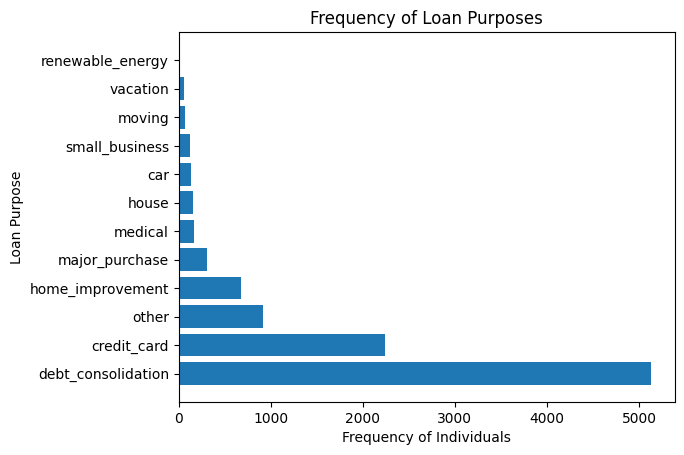

In [11]:
#bar plot to show most common loan_purpose
loans_df['loan_purpose'].unique()
values = loans_df['loan_purpose'].value_counts()
plt.barh(values.index, values.values)
plt.ylabel('Loan Purpose')
plt.xlabel('Frequency of Individuals')
plt.title('Frequency of Loan Purposes')
plt.show()

**Observations**


*   Most common loan purpose: debt consolidation and credit card (more than half individuals use for debt)



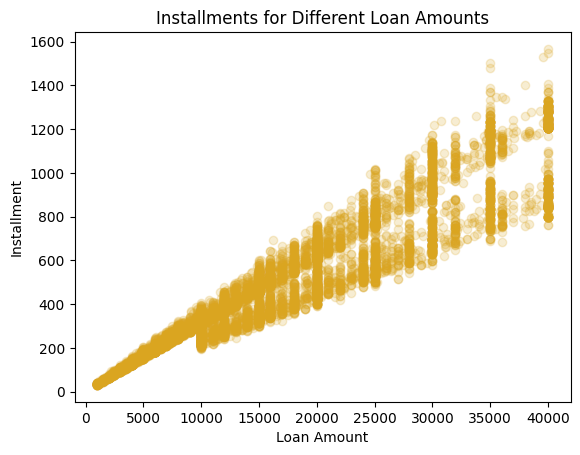

In [16]:
#scatterplot to show relationship between loan_amount and installment
plt.scatter(loans_df['loan_amount'], loans_df['installment'], color='goldenrod', alpha=0.2)
plt.xlabel('Loan Amount')
plt.ylabel('Installment')
plt.title('Installments for Different Loan Amounts')
plt.show()

**Observations**
*    As loan amount increases, installment amount increases
*    Max loan amount is still 40,000

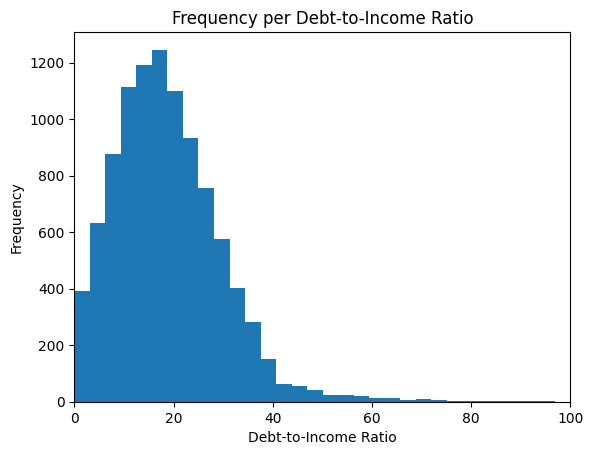

In [13]:
#histogram showing debt_to_income
plt.hist(loans_df['debt_to_income'], bins = 150)
plt.xlabel('Debt-to-Income Ratio')
plt.ylabel('Frequency')
plt.title('Frequency per Debt-to-Income Ratio')
plt.xlim(0, 100)
plt.xticks
plt.show()

**Observations**
*    Distribution: skewed right; unimodal
*    Most common debt-to-income ratio clustered around 20

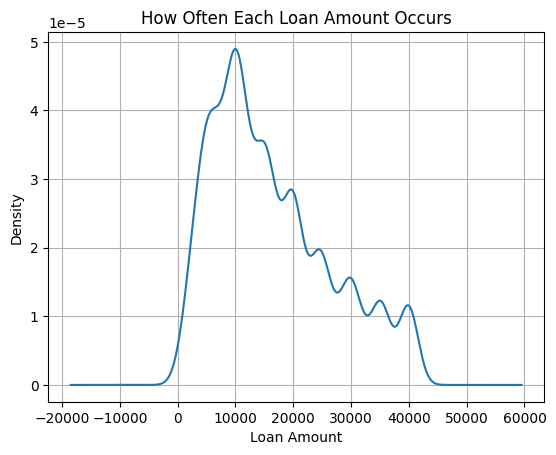

In [26]:
#dot density plot
loans_df['loan_amount'].plot(kind='density')
plt.xlabel('Loan Amount')
plt.title('How Often Each Loan Amount Occurs')
plt.grid(True)
plt.show()

**Observations**
*    Common loan amount = 10,000
*    Slightly skewed right distribution
*    Mostly unimodal

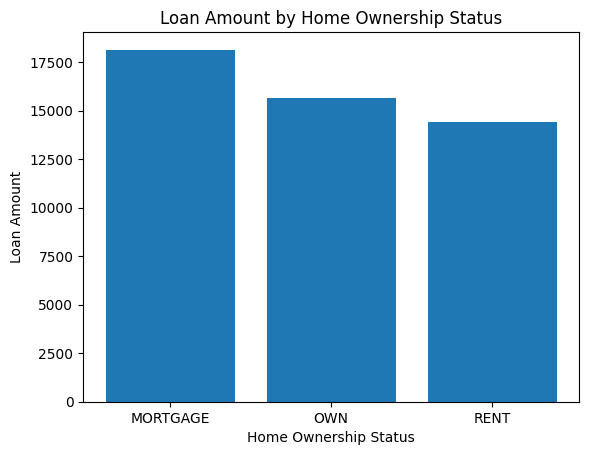

In [24]:
#if home ownership affects MEAN loan amount
means = loans_df.groupby('homeownership')['loan_amount'].mean()
plt.bar(means.index, means.values)
plt.xlabel('Home Ownership Status')
plt.ylabel('Loan Amount')
plt.title('Loan Amount by Home Ownership Status')
plt.show()

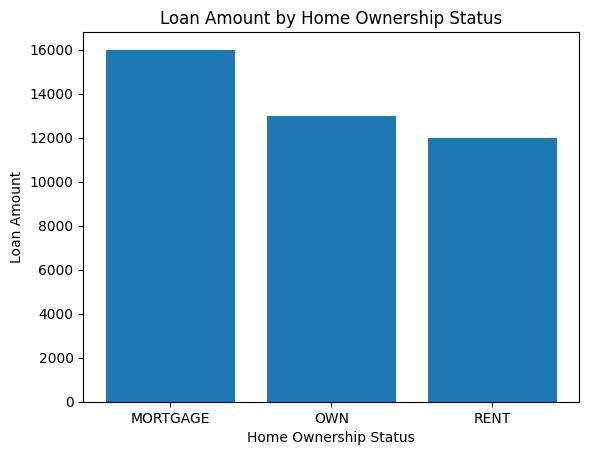

In [27]:
#if home ownership affects MEDIAN loan amount
medians = loans_df.groupby('homeownership')['loan_amount'].median()
plt.bar(medians.index, medians.values)
plt.xlabel('Home Ownership Status')
plt.ylabel('Loan Amount')
plt.title('Loan Amount by Home Ownership Status')
plt.show()

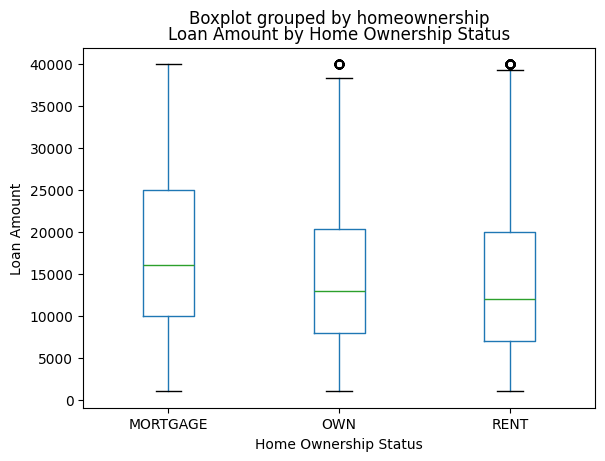

In [31]:
#use a box plot to confirm home ownership/loan amount trend
loans_df.boxplot(column='loan_amount', by='homeownership', grid=False)
plt.xlabel('Home Ownership Status')
plt.ylabel('Loan Amount')
plt.title('Loan Amount by Home Ownership Status')
plt.show()

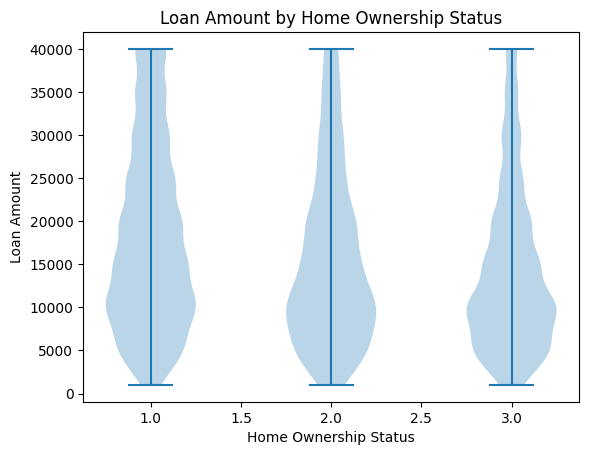

In [32]:
#use a violin plot to confirm home ownership/loan amount trend
groups = loans_df.groupby('homeownership')['loan_amount'].apply(list)
plt.violinplot(groups)
plt.xlabel('Home Ownership Status')
plt.ylabel('Loan Amount')
plt.title('Loan Amount by Home Ownership Status')
plt.show()

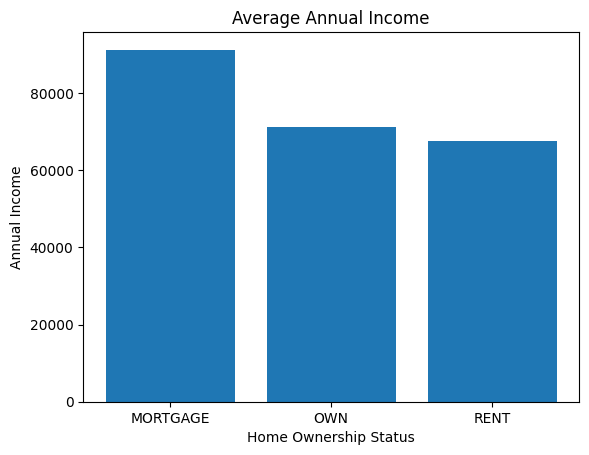

In [36]:
#compare mortgage holders annual incomes VS others
means = loans_df.groupby('homeownership')['annual_income'].mean()
plt.bar(means.index, means.values)
plt.xlabel('Home Ownership Status')
plt.ylabel('Annual Income')
plt.title('Average Annual Income')
plt.show()